# Dog Bounding Box Detection
Uses a pre-trained YOLOv5 model to detect dogs and draw bounding boxes.

In [ ]:
%pip install torch torchvision ultralytics requests pillow matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO('yolov8n.pt')

# Load font
font = ImageFont.truetype("/Library/Fonts/Arial.ttf", 40)


0: 640x512 1 dog, 422.1ms
Speed: 19.7ms preprocess, 422.1ms inference, 24.0ms postprocess per image at shape (1, 3, 640, 512)


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


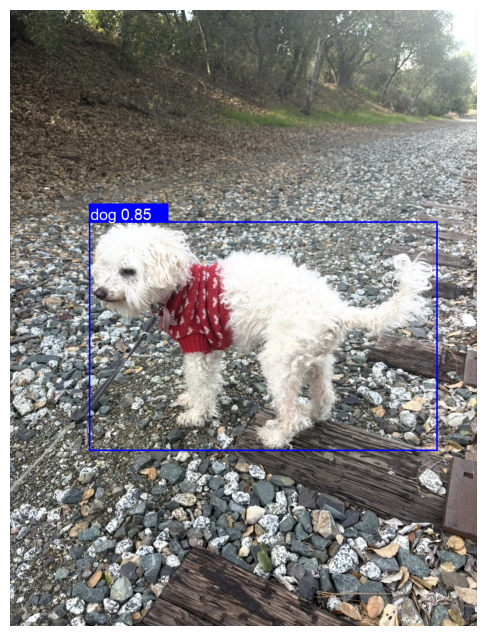

In [3]:
# Load dog image
img = Image.open("files/wynnie.jpg").convert("RGB")

# Run inference
results = model(img)

# Draw bounding boxes for dogs
draw = ImageDraw.Draw(img)
dog_count = 0

for result in results:
    for box in result.boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        conf = float(box.conf[0])

        if label == 'dog' and conf > 0.5:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            draw.rectangle([x1, y1, x2, y2], outline="blue", width=4)
            draw.rectangle([x1, y1 - 45, x1 + 200, y1], fill="blue")
            draw.text((x1 + 4, y1 - 40), f"{label} {conf:.2f}", fill="white", font=font)

# Display result
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.show()